In [1]:
import warnings
from dataPreparation import getMGData, getNetwork
import numpy as np
from itertools import product
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
import pandas as pd
from tqdm import tqdm

#### Auto Reloading for External Libraries

In [2]:
# Using this magic command, we turn on auto-reloading for libraries imported by %aimport
%load_ext autoreload
%autoreload 1
# Can be reloaded multiple times
%aimport NonDecomposed
%aimport HigherLevelModel
%aimport LowerLevelModel
%aimport dataPreparation

In [3]:
I = 3 # Number of MGs
SH, PH, CH = 24, 4, 1  # Scheduling horizon, Prediction horizon, Control Horizon
thetas = {'r': 0.8, 'c':0.2}
i_list = range(I)
t_list = range(SH)

### Non-Decomposed Model CTP

In [4]:
data_mgs = {i: getMGData(i) for i in range(I)}
data_net_min, data_net_max= getNetwork()
results = {'item': [f'MG {i}' for i in range(I)],
           'resilience before': np.zeros(I), 'resilience after': np.zeros(I),
           'cost before': np.zeros(I), 'cost after': np.zeros(I)}

In [5]:
# arguments to pass to NonDecomposed with no trade
non_dec_no_trade_params = {'data': data_mgs, 'mgs_count': I,
                            'scheduling_horizon': SH,
                            'r_dis_points': dict.fromkeys(i_list, 0),
                            'c_dis_points': dict.fromkeys(i_list, 0),
                            'trade': False}
non_dec_trade_params = non_dec_no_trade_params.copy()

In [6]:
from NonDecomposed import NonDecomposed
ndm_0 = NonDecomposed(mgs_count=I, data=data_mgs,
                      scheduling_horizon=SH,
                      r_dis_points=dict.fromkeys(i_list, 0),
                      c_dis_points=dict.fromkeys(i_list, 0),
                      trade=False)
ndm_0.model.optimize()
for i in range(I):
    results['resilience before'][i] = ndm_0.eta_r[i].x
    results['cost before'][i] = ndm_0.eta_c[i].x
    data_mgs[i]['eta_r_Non'] = ndm_0.eta_r[i].x
    data_mgs[i]['eta_c_Non'] = ndm_0.eta_c[i].x


from NonDecomposed import NonDecomposed
ndm_1 = NonDecomposed(mgs_count=I, data=data_mgs,
                      scheduling_horizon=SH,
                      r_dis_points=results['resilience before'],
                      c_dis_points=results['cost before'],
                      trade=True)
ndm_1.model.optimize()
for i in range(I):
    results['resilience after'][i] = ndm_1.eta_r[i].x
    results['cost after'][i] = ndm_1.eta_c[i].x

Set parameter Username
Academic license - for non-commercial use only - expires 2025-02-26
Set parameter NonConvex to value 2
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 669 rows, 525 columns and 1614 nonzeros
Model fingerprint: 0xe3bef3da
Coefficient statistics:
  Matrix range     [2e-06, 2e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e-01, 2e+04]
Presolve removed 528 rows and 133 columns
Presolve time: 0.00s
Presolved: 141 rows, 392 columns, 593 nonzeros

Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    9.2860385e-01   1.876622e+03   0.000000e+00      0s
Extra simplex iterations after uncrush: 1
     134    6.7505948e-01   0.000000e+00   0.000000e+00      0s

Solved in 134 iterations and 0.01 seconds (0.00 work un

In [7]:
pd.DataFrame(results)

,item,resilience before,resilience after,cost before,cost after
0,MG 0,0.424837,0.843010,0.535421,0.540183
1,MG 1,0.783132,0.783132,0.494520,0.494520
2,MG 2,1.000000,1.000000,0.446517,0.446517


## Decomposed Model - ADMM implementation

In [8]:
def checkConvergence(x1, x2, epsilon, rho):
    x = np.abs(x1 - x2)
    x_second_norm = rho * (x ** 2).sum()
    violated = (x > epsilon).sum()
    return violated, x_second_norm

In [9]:
epsilon = 0.001
mu = 10  # rho update constant
tau_incr, tau_decr = 2, 2  # rho update parameters
ijt_array_0 = np.array(I * [np.array(I * [np.array(SH * [0.0])])])
lambdas = {'l_e_buy': ijt_array_0.copy(),
           'l_e_sell': ijt_array_0.copy(),
           'l_pi_buy': ijt_array_0.copy(),
           'l_pi_sell': ijt_array_0.copy()}

e_values = {'e_buy': ijt_array_0.copy(), 'e_sell': ijt_array_0.copy()}
pi_values = {'pi_buy': ijt_array_0.copy(), 'pi_sell': ijt_array_0.copy()}

e_hat_values = {'e_buy': ijt_array_0.copy(), 'e_sell': ijt_array_0.copy()}
pi_hat_values = {'pi_buy': ijt_array_0.copy(), 'pi_sell': ijt_array_0.copy()}

In [ ]:
from LowerLevelModel import LowerLevelModel
from HigherLevelModel import HigherLevelModel

current_iteration, max_iterations = 1, 20
gaps = []
res = {'p': [],'d': []}
rhos = {'e': 0.00001, 'pi': 0.00001}
lems_models = np.array([LowerLevelModel(mg_id=i, mg_data=data_mgs[i],
                                        mg_count=I, thetas=thetas,
                                        scheduling_horizon=SH) for i in i_list])
cems_model = HigherLevelModel(mg_count=I, scheduling_horizon=SH)
with tqdm(total=max_iterations, desc="Processing") as pbar:
    while not cems_model.done or current_iteration <= max_iterations:
        # solve each microgrid problem individually
        for i in i_list:
            m = lems_models[i]
            m.buildLagrangianTerms(e_buy_hat=e_hat_values['e_buy'][i], e_sell_hat=e_hat_values['e_sell'][i],
                                   pi_buy_hat=pi_hat_values['pi_buy'][i], pi_sell_hat=pi_hat_values['pi_sell'][i],
                                   l_e_buy=lambdas['l_e_buy'][i], l_e_sell=lambdas['l_e_sell'][i],
                                   l_pi_buy=lambdas['l_pi_buy'][i], l_pi_sell=lambdas['l_pi_sell'][i],
                                   rhos=rhos)
            m.updateObjective()
            m.model.optimize()
            if m.model.status in ['INFEASIBLE', 'INF_OR_UNBD', 'UNBOUNDED']:
                raise ValueError(f"MG {i} status: {m.model.status}")
            e_values['e_buy'][i], e_values['e_sell'][i], pi_values['pi_buy'][i], pi_values['pi_sell'][i] = m.getVarValues()
        e_pi = np.concatenate((list(e_values.values()), list(pi_values.values())))

        # solve higher level problem
        cems_model.buildObjective(e_values=e_values, pi_values=pi_values, lambdas=lambdas, rhos=rhos)
        cems_model.model.optimize()

        # save old hat vars and get new hat vars
        e_pi_hat_old = np.concatenate((list(e_hat_values.values()), list(pi_hat_values.values())))
        e_hat_values, pi_hat_values = cems_model.getVarValues()
        e_pi_hat_new = np.concatenate((list(e_hat_values.values()), list(pi_hat_values.values())))

        # check convergence and keep primal and dual residuals
        violated_primal_vars, primal_res = checkConvergence(e_pi, e_pi_hat_new, epsilon=epsilon, rho=1)
        violated_dual_vars, dual_res = checkConvergence(e_pi_hat_new, e_pi_hat_old, epsilon=epsilon, rho=rhos['e'])
        gaps.append(violated_primal_vars)
        res['p'].append(primal_res)
        res['d'].append(dual_res)
        if violated_primal_vars == 0:
            cems_model.done = True

        # update lambdas
        lambdas = cems_model.updateLambdas(e_values=e_values, pi_values=pi_values,
                                           e_hat_values=e_hat_values, pi_hat_values=pi_hat_values,
                                           lambdas=lambdas, rhos=rhos)
        # update rhos
        if primal_res >= mu * dual_res:
            rhos['e'] *= tau_incr
            rhos['pi'] *= tau_incr
        elif primal_res >= mu * dual_res:
            rhos['e'] /= tau_decr
            rhos['pi'] /= tau_decr
        else:
            pass
        # update k and pbar
        current_iteration += 1
        pbar.update(1)

Processing:  15%|█▌        | 3/20 [00:01<00:07,  2.34it/s]

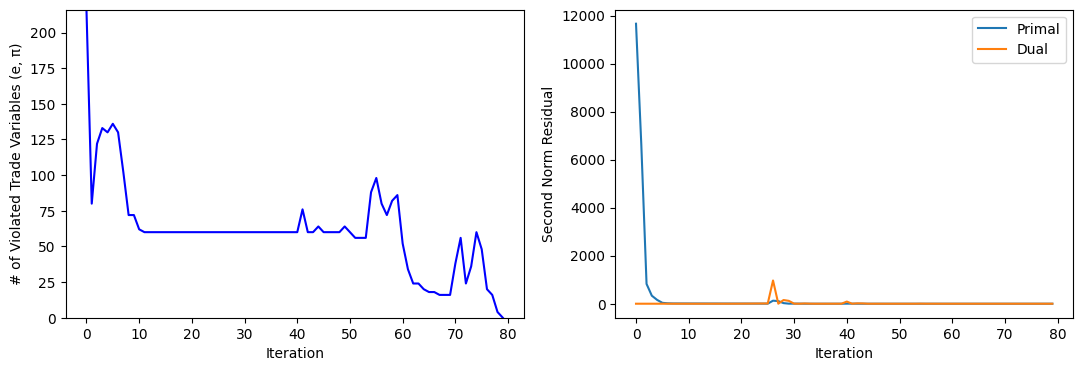

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(gaps, color='blue')
ax[0].set_ylabel('# of Violated Trade Variables (e, \u03c0)')
ax[0].set_xlabel('Iteration')
ax[0].set_ylim([0, 4*I*I*SH])

ax[1].plot(pd.DataFrame(res))
ax[1].set_ylabel('Second Norm Residual')
ax[1].set_xlabel('Iteration')
ax[1].legend(['Primal', 'Dual'])

In [43]:
from gurobipy import GRB
import gurobipy as gp
from gurobipy import quicksum

In [89]:
lems_models[0].model.optimize()

In [99]:
print(lems_models[2].eta_r)
#lems_models[0].model.getRow(lems_models[0].model.getConstrByName('eta_r'))

<gurobi.Var eta_r (value 0.7981472624546323)>


In [96]:
data_mgs[0]['eta_r_Non']

0.7011708790665878

In [223]:
test_model = gp.Model()
X = test_model.addVars(2, 4, ub=1)
test_model.update()
test_model.setObjective(quicksum(X))
test_model.optimize()
#test_model.getAttr('X', X.values())


Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (win64)

CPU model: Intel(R) Core(TM) i7-10510U CPU @ 1.80GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 0 rows, 8 columns and 0 nonzeros
Model fingerprint: 0x3a57a173
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Presolve removed 0 rows and 8 columns
Presolve time: 0.01s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    0.0000000e+00   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.01 seconds (0.00 work units)
Optimal objective  0.000000000e+00


In [224]:
test_model.getAttr('X', X.values())

[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

In [89]:
mm = LowerLevelProblem(mg_id=0, mg_data=data_mgs[0], thetas=thetas, rhos=rhos)
mm.model.optimize()

In [167]:
nn = np.array([[1, 1],[2, 2]])
mm = np.array([[1, 1],[2, 2]])
np.concatenate((nn, mm), axis=0)

array([[1, 1],
       [2, 2],
       [1, 1],
       [2, 2]])